# L14 — Spoiler & Crusher Gradients, Contrast Agents (+ a Safety Sanity-Check)

**Module 3 · Day 20 · MRI1 Lecture 14 (F. Laun, FAU Erlangen-Nürnberg)**

This notebook makes the last MRI 1 lecture *runnable*. We will:

1. **Spoiler gradients** — show how an integer number of $2\pi$ phase twists across a voxel makes the voxel-averaged signal vanish, and reproduce the residual-signal **sinc** curve.
2. **Crusher gradients** — demonstrate why a *balanced pair* around a 180° pulse keeps the wanted echo but crushes the spurious FID.
3. **Contrast agents** — implement the relaxivity law $R_{i,\text{obs}}=R_{i,\text{int}}+r_iC$, reproduce the lecture's exact numbers ($T_1\!:1000\to274$ ms, $T_2\!:100\to79$ ms), and show *why Gd is a $T_1$ agent*.
4. **Safety** — a couple of quantitative sanity checks (Larmor at 7 T, why RF power grows with field).

Everything runs on synthetic data — no downloads needed. Run it **cell by cell**, then change the parameters and watch what breaks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
rng = np.random.default_rng(14)  # reproducible 'noise' where used
print("Ready. numpy", np.__version__)

Ready. numpy 2.4.4


---
## 1. Spoiler gradients

A spoiler is a gradient pulse fired at the end of TR to kill leftover transverse magnetization $M_+$.
A gradient $G$ on for a time $\tau$ gives a spin at position $x$ the phase

$$\varphi(x) = \gamma\,G\,\tau\,x ,$$

i.e. phase varies **linearly across the voxel**. If the *total* spread across a voxel of width $\Delta x$ is

$$\Delta\varphi = \gamma\,G\,\tau\,\Delta x = 2\pi n,$$

the transverse vectors inside the voxel fan out into $n$ complete turns and **sum to zero**.

First, let's literally draw the arrows for a few values of the dephasing — the slide's picture.

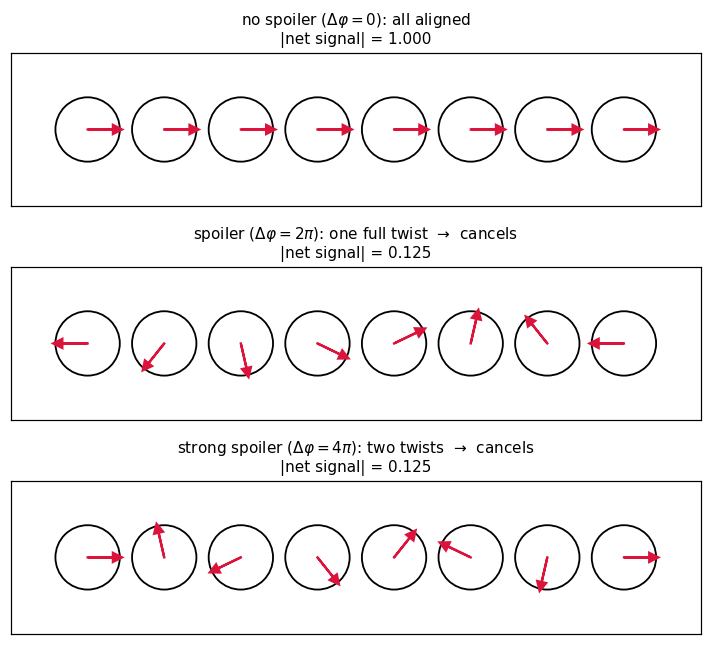

In [2]:
def voxel_arrows(ax, dphi, n_spins=8, title=""):
    # spins evenly spaced across the voxel, phase = dphi * (position in [-0.5, 0.5])
    pos = np.linspace(-0.5, 0.5, n_spins)
    phase = dphi * pos
    xs = np.arange(n_spins)
    for x, p in zip(xs, phase):
        ax.add_patch(plt.Circle((x, 0), 0.42, fill=False, lw=1.2))
        ax.arrow(x, 0, 0.33*np.cos(p), 0.33*np.sin(p),
                 head_width=0.12, head_length=0.12, fc='crimson', ec='crimson', lw=1.5)
    net = np.mean(np.exp(1j*phase))
    ax.set_xlim(-1, n_spins); ax.set_ylim(-1, 1); ax.set_aspect('equal')
    ax.set_yticks([]); ax.set_xticks([]); ax.grid(False)
    ax.set_title(f"{title}\n|net signal| = {abs(net):.3f}", fontsize=10)

fig, axes = plt.subplots(3, 1, figsize=(8, 6))
voxel_arrows(axes[0], 0.0,        title=r"no spoiler ($\Delta\varphi=0$): all aligned")
voxel_arrows(axes[1], 2*np.pi,    title=r"spoiler ($\Delta\varphi=2\pi$): one full twist  →  cancels")
voxel_arrows(axes[2], 4*np.pi,    title=r"strong spoiler ($\Delta\varphi=4\pi$): two twists  →  cancels")
plt.tight_layout(); plt.show()

The middle and bottom rows are the lecture's "zero signal" arrows: spread the phase over a whole number of turns and the average vector is the centre of the circle — nothing.

Now the quantitative version. For a uniform voxel the averaged signal is

$$S(\Delta\varphi)=\frac{1}{\Delta x}\int_{-\Delta x/2}^{\Delta x/2} e^{\,i(\Delta\varphi/\Delta x)x}\,dx=\operatorname{sinc}\!\Big(\tfrac{\Delta\varphi}{2}\Big),$$

a **sinc with zeros at every $\Delta\varphi=2\pi n$.**

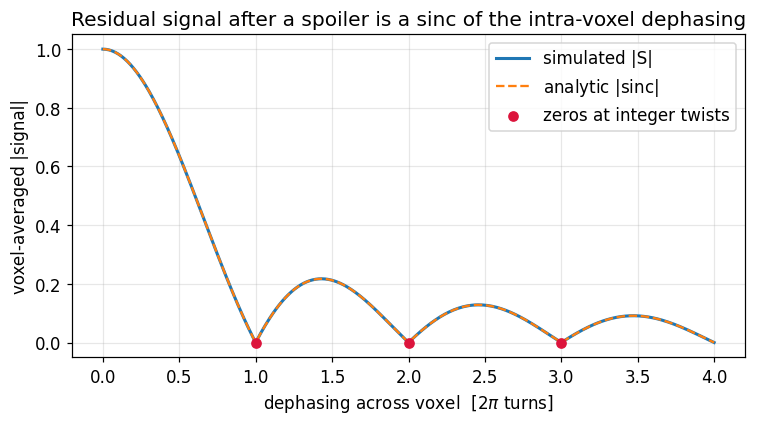

first-twist residual |S| at 1 turn : 5.00e-05  (~0)
half-twist residual  |S| at 0.5 turn: 0.637  (sinc(0.5)=0.637)


In [3]:
def voxel_signal(dphi, n=20001):
    # voxel-averaged transverse signal for a linear phase ramp of total spread dphi
    x = np.linspace(-0.5, 0.5, n)
    return np.mean(np.exp(1j * dphi * x))

twists = np.linspace(0, 4, 400)          # number of 2*pi turns across the voxel
dphi   = 2*np.pi*twists
S      = np.array([abs(voxel_signal(d)) for d in dphi])

plt.figure()
plt.plot(twists, S, lw=2, label="simulated |S|")
plt.plot(twists, np.abs(np.sinc(twists)), '--', label=r"analytic $|\mathrm{sinc}|$")
plt.scatter([1,2,3], [0,0,0], color='crimson', zorder=5, label="zeros at integer twists")
plt.xlabel(r"dephasing across voxel  [$2\pi$ turns]")
plt.ylabel("voxel-averaged |signal|")
plt.title("Residual signal after a spoiler is a sinc of the intra-voxel dephasing")
plt.legend(); plt.tight_layout(); plt.show()

print("first-twist residual |S| at 1 turn :", f"{abs(voxel_signal(2*np.pi)):.2e}  (~0)")
print("half-twist residual  |S| at 0.5 turn:", f"{abs(voxel_signal(np.pi)):.3f}  (sinc(0.5)=0.637)")

**Read it off:** you don't need a giant gradient — you need an *integer* number of $2\pi$ wraps. Half a turn ($\Delta\varphi=\pi$) only knocks the signal down to ~0.64; the spoiler has to reach a full $2\pi$ (or a multiple) to truly null it. *(This answers self-test Q2 and Q3.)*

> Note: a gradient spoiler dephases but does **not destroy** the magnetization — stimulated echoes can refocus it later. Robust steady-state spoiling adds **RF spoiling** too. That's MRI 2.

---
## 2. Crusher gradients

Slice profiles are imperfect: a nominal 180° refocusing pulse is only ~180° in the middle of the slice and closer to 90° at the edges. A non-180° flip tips fresh magnetization into the plane → a **spurious FID** that rides on top of the wanted spin echo and wrecks the image.

A **crusher** is a *balanced pair* of lobes around the 180° pulse. The trick is that the two signals see **different total gradient moments**:

* **Wanted echo:** inverted by the (good) 180° between the lobes → first lobe's phase is reversed, then **undone** by the second lobe → **net-zero moment → echo survives.**
* **Spurious FID:** created *at* the imperfect pulse → only sees the **second lobe** → picks up a $2\pi n$ dephasing → **crushed to zero.**

Let's model both pathways as a function of crusher strength.

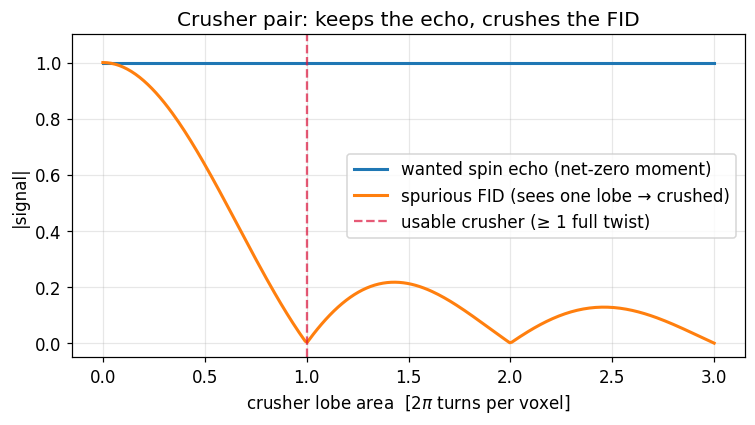

In [4]:
# Model: crusher gives each lobe a per-voxel dephasing 'm' (in units of 2*pi turns).
# Wanted echo sees +m then (after 180 inversion) effectively -m  -> net 0, regardless of m.
# Spurious FID is born at the pulse and only sees the SECOND lobe -> net dephasing m.
m = np.linspace(0, 3, 300)                      # crusher area, in 2*pi turns per voxel

echo_signal = np.array([abs(voxel_signal(0.0)) for _ in m])          # always net 0 -> full echo
fid_signal  = np.array([abs(voxel_signal(2*np.pi*mi)) for mi in m])  # crushed like a spoiler

plt.figure()
plt.plot(m, echo_signal, lw=2, label="wanted spin echo (net-zero moment)")
plt.plot(m, fid_signal,  lw=2, label="spurious FID (sees one lobe → crushed)")
plt.axvline(1, color='crimson', ls='--', alpha=0.7, label="usable crusher (≥ 1 full twist)")
plt.xlabel(r"crusher lobe area  [$2\pi$ turns per voxel]")
plt.ylabel("|signal|")
plt.title("Crusher pair: keeps the echo, crushes the FID")
plt.legend(); plt.ylim(-0.05, 1.1); plt.tight_layout(); plt.show()

The blue line never moves — the balanced pair is transparent to the true echo. The orange line is crushed exactly like a spoiler once the lobe reaches a full $2\pi$ twist. That separation is the whole point of crushers. *(Self-test Q4–Q5.)*

A quick picture of the artifact itself: the FID contamination is roughly proportional to how far the edge flip angle departs from 180°.

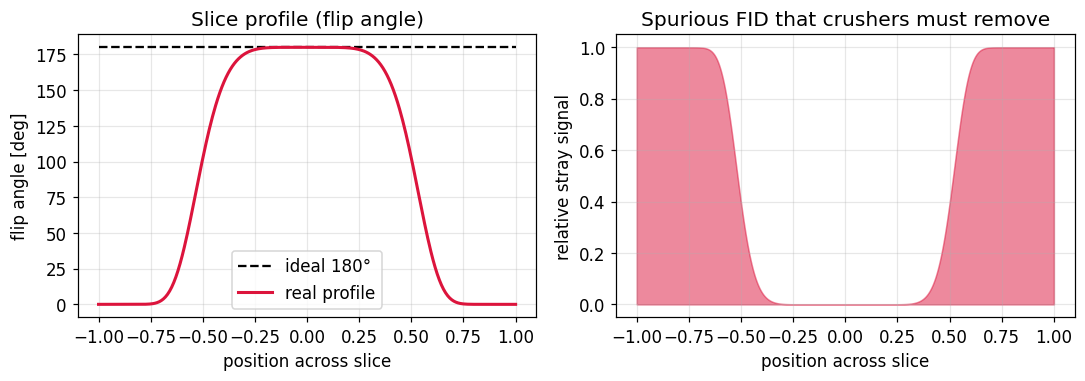

In [5]:
# Toy 1-D 'slice profile': flip angle vs position. Ideal = 180 everywhere; reality droops at edges.
x = np.linspace(-1, 1, 400)
ideal   = np.full_like(x, 180.0)
real    = 180.0 * np.exp(-(x/0.55)**6)          # flat-ish top, soft shoulders -> ~90 deg at edges
# Spurious transverse magnetization from an imperfect refocus ~ sin(flip/2)^2-style leakage:
leak    = np.sin(np.deg2rad((180 - real))/2)**2   # 0 where flip is a true 180, grows at edges

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(x, ideal, 'k--', label="ideal 180°")
ax[0].plot(x, real, 'crimson', lw=2, label="real profile")
ax[0].set_title("Slice profile (flip angle)"); ax[0].set_xlabel("position across slice")
ax[0].set_ylabel("flip angle [deg]"); ax[0].legend()
ax[1].fill_between(x, leak, color='crimson', alpha=0.5)
ax[1].set_title("Spurious FID that crushers must remove"); ax[1].set_xlabel("position across slice")
ax[1].set_ylabel("relative stray signal")
plt.tight_layout(); plt.show()

---
## 3. Contrast agents (gadolinium)

Gd³⁺ **shortens relaxation times** of nearby water. The observed *rates* grow linearly with concentration $C$:

$$R_{1,\text{obs}}=R_{1,\text{int}}+r_1C,\qquad R_{2,\text{obs}}=R_{2,\text{int}}+r_2C.$$

Lecture values (Gadovist in blood @ 1.5 T, Rohrer et al. 2005): $r_1=5.3$, $r_2=5.4$ mM⁻¹s⁻¹.

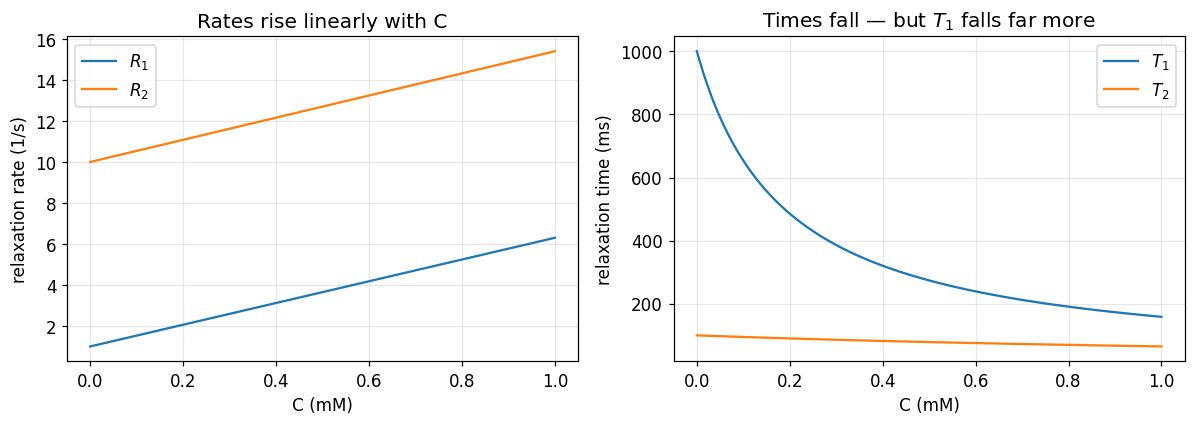

In [6]:
r1, r2 = 5.3, 5.4            # mM^-1 s^-1
T1_int, T2_int = 1.000, 0.100   # s   (1000 ms, 100 ms)
R1_int, R2_int = 1/T1_int, 1/T2_int

C = np.linspace(0, 1, 200)      # mM
R1 = R1_int + r1*C
R2 = R2_int + r2*C

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(C, R1, label=r"$R_1$"); ax[0].plot(C, R2, label=r"$R_2$")
ax[0].set_xlabel("C (mM)"); ax[0].set_ylabel("relaxation rate (1/s)")
ax[0].set_title("Rates rise linearly with C"); ax[0].legend()

ax[1].plot(C, 1000/R1, label=r"$T_1$"); ax[1].plot(C, 1000/R2, label=r"$T_2$")
ax[1].set_xlabel("C (mM)"); ax[1].set_ylabel("relaxation time (ms)")
ax[1].set_title("Times fall — but $T_1$ falls far more"); ax[1].legend()
plt.tight_layout(); plt.show()

These reproduce the two lecture plots (rate-vs-C and time-vs-C). Now the worked example, with assertions so we *prove* we match the slide.

In [7]:
C0 = 0.5  # mM
T1_obs = 1/(R1_int + r1*C0)
T2_obs = 1/(R2_int + r2*C0)
print(f"At C = {C0} mM:")
print(f"  T1: {T1_int*1000:.0f} ms  ->  {T1_obs*1000:.0f} ms   (lecture: 274 ms)")
print(f"  T2: {T2_int*1000:.0f} ms  ->  {T2_obs*1000:.0f} ms    (lecture: 79 ms)")

assert abs(T1_obs*1000 - 274) < 1, "T1 mismatch"
assert abs(T2_obs*1000 - 79)  < 1, "T2 mismatch"
print("\nMatches the lecture exactly.")

At C = 0.5 mM:
  T1: 1000 ms  ->  274 ms   (lecture: 274 ms)
  T2: 100 ms  ->  79 ms    (lecture: 79 ms)

Matches the lecture exactly.


**Why is Gd a $T_1$ agent even though $r_1\approx r_2$?** Look at the *relative* change. The same added rate (~2.7 s⁻¹) is enormous next to the small intrinsic $R_1$ but minor next to the large intrinsic $R_2$.

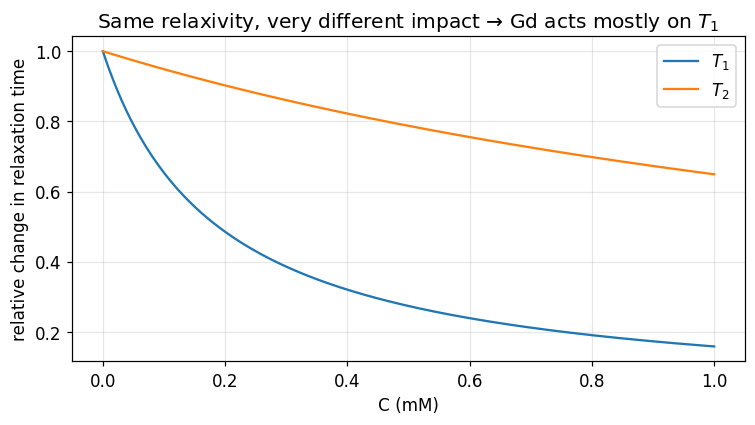

At 0.5 mM: T1 drops to   27% of baseline
           T2 drops to   79% of baseline


In [8]:
rel_T1 = (1/(R1_int + r1*C)) / T1_int   # T1_obs / T1_int
rel_T2 = (1/(R2_int + r2*C)) / T2_int

plt.figure()
plt.plot(C, rel_T1, label=r"$T_1$")
plt.plot(C, rel_T2, label=r"$T_2$")
plt.xlabel("C (mM)"); plt.ylabel("relative change in relaxation time")
plt.title("Same relaxivity, very different impact → Gd acts mostly on $T_1$")
plt.legend(); plt.tight_layout(); plt.show()

print(f"At 0.5 mM: T1 drops to {rel_T1[np.argmin(abs(C-0.5))]*100:4.0f}% of baseline")
print(f"           T2 drops to {rel_T2[np.argmin(abs(C-0.5))]*100:4.0f}% of baseline")

### What this does to an image: $T_1$-weighted enhancement

Use the steady-state **spoiled gradient-echo (SPGR)** signal

$$S = M_0\,\sin\alpha\;\frac{1-E_1}{1-\cos\alpha\,E_1},\qquad E_1=e^{-\mathrm{TR}/T_1}.$$

Shortening $T_1$ (more contrast agent) *raises* the signal → tissue lights up. This is exactly the "leaky tumour goes bright" story.

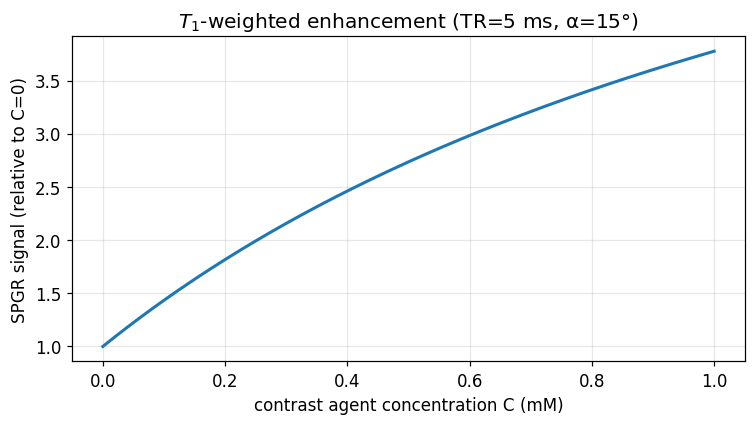

Enhancement at 0.5 mM: x2.74 brighter than baseline


In [9]:
def spgr(T1, alpha_deg, TR, M0=1.0):
    a = np.deg2rad(alpha_deg); E1 = np.exp(-TR/T1)
    return M0*np.sin(a)*(1-E1)/(1-np.cos(a)*E1)

TR, alpha = 0.005, 15.0   # s, deg  (a fast T1-weighted SPGR)
T1_of_C = 1/(R1_int + r1*C)
S_of_C  = spgr(T1_of_C, alpha, TR)

plt.figure()
plt.plot(C, S_of_C/S_of_C[0], lw=2)
plt.xlabel("contrast agent concentration C (mM)")
plt.ylabel("SPGR signal (relative to C=0)")
plt.title(f"$T_1$-weighted enhancement (TR={TR*1000:.0f} ms, α={alpha:.0f}°)")
plt.tight_layout(); plt.show()

print(f"Enhancement at 0.5 mM: x{S_of_C[np.argmin(abs(C-0.5))]/S_of_C[0]:.2f} brighter than baseline")

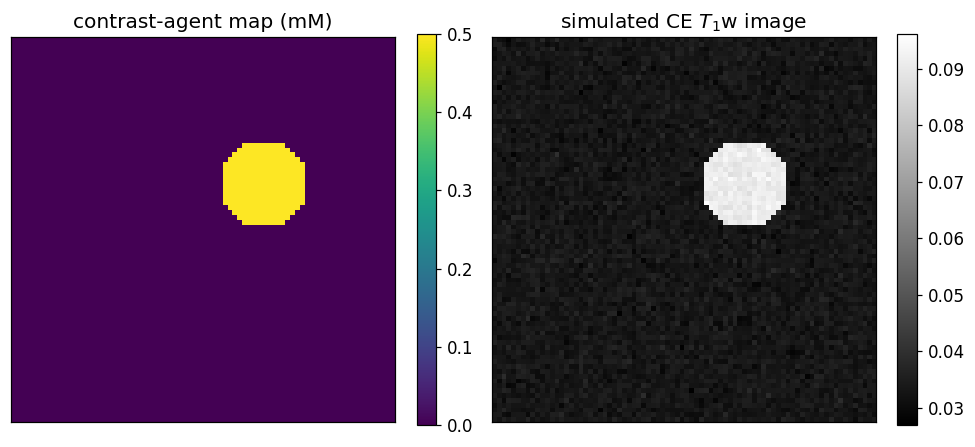

The lesion is bright on the T1w image purely because its T1 was shortened.


In [10]:
# A tiny 2-compartment 'phantom': healthy tissue vs leaky tumour that took up agent.
img = np.zeros((80, 80))
yy, xx = np.mgrid[0:80, 0:80]
tissue = np.ones_like(img)                              # background tissue, C = 0
tumour = ((xx-52)**2 + (yy-30)**2) < 9**2               # leaky lesion, C = 0.5 mM
C_map = np.where(tumour, 0.5, 0.0)

T1_map = 1/(R1_int + r1*C_map)
S_map  = spgr(T1_map, alpha, TR)
S_map += rng.normal(0, S_map.max()*0.02, S_map.shape)   # a touch of noise

fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
im0 = ax[0].imshow(C_map, cmap="viridis"); ax[0].set_title("contrast-agent map (mM)")
plt.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(S_map, cmap="gray");    ax[1].set_title("simulated CE $T_1$w image")
plt.colorbar(im1, ax=ax[1], fraction=0.046)
for a in ax: a.set_xticks([]); a.set_yticks([]); a.grid(False)
plt.tight_layout(); plt.show()
print("The lesion is bright on the T1w image purely because its T1 was shortened.")

---
## 4. Safety — two quick sanity checks

No simulation can substitute for the rules (and **never enter the scanner room with a ferromagnetic object**), but two numbers explain *why* high field is harder.

In [11]:
gamma_bar = 42.577e6   # Hz/T, proton gyromagnetic ratio / 2pi
for B0 in [1.5, 3.0, 7.0]:
    f = gamma_bar * B0
    print(f"B0 = {B0:>4.1f} T  ->  Larmor frequency = {f/1e6:6.1f} MHz")

print("\nRF power deposition (SAR) scales roughly with (B0 * flip_angle)^2:")
ref = (1.5*90)**2
for B0 in [1.5, 3.0, 7.0]:
    print(f"  at {B0} T, same 90 deg pulse  ->  ~{(B0*90)**2/ref:4.1f}x the 1.5 T SAR")
print("\nThat steep growth is why SAR limits bite hardest at 7 T — and why the scanner monitors them.")

B0 =  1.5 T  ->  Larmor frequency =   63.9 MHz
B0 =  3.0 T  ->  Larmor frequency =  127.7 MHz
B0 =  7.0 T  ->  Larmor frequency =  298.0 MHz

RF power deposition (SAR) scales roughly with (B0 * flip_angle)^2:
  at 1.5 T, same 90 deg pulse  ->  ~ 1.0x the 1.5 T SAR
  at 3.0 T, same 90 deg pulse  ->  ~ 4.0x the 1.5 T SAR
  at 7.0 T, same 90 deg pulse  ->  ~21.8x the 1.5 T SAR

That steep growth is why SAR limits bite hardest at 7 T — and why the scanner monitors them.


**Takeaways the scanner can't enforce for you:** the static $B_0$ field is always on and respects no software limit — hence the missile effect is the dominant hazard. **Magnet Stop** quenches $B_0$ (last resort, expensive, helium boil-off → suffocation risk); **Not-Aus MRT** cuts the electronics but leaves $B_0$ on (use for water/smoke). *(Self-test Q9–Q10.)*

---
## 5. Try it on real data (optional)

Everything above is synthetic and self-contained. To take it further:

- **Relaxivity from real data:** if you have multi-flip-angle or inversion-recovery acquisitions of a Gd phantom dilution series, fit $1/T_1$ vs $C$ — the slope *is* $r_1$. (The IXI / fastMRI sets don't include CA series; a doped-phantom dataset or your lab's QA scans are ideal.)
- **Spoiler/crusher in a real sequence:** open a vendor sequence diagram and identify the end-of-TR spoiler and the crusher pair flanking each 180°. Check that the crusher lobes are equal-area.
- **Push the spoiler model:** add a *distribution* of voxel sizes or off-resonance and watch the sinc nulls blur — that's why real spoiling pairs gradient + RF spoiling.

## Recap

| Concept | One line | Knob you turned |
|---|---|---|
| Spoiler | $2\pi n$ dephasing nulls voxel $M_+$; residual is a sinc | total intra-voxel phase $\Delta\varphi$ |
| Crusher | balanced pair: echo survives (net-zero), FID crushed | lobe area in $2\pi$ turns |
| Contrast | $R_{i,\text{obs}}=R_{i,\text{int}}+r_iC$; mostly a $T_1$ effect | concentration $C$ |
| CE imaging | shorter $T_1$ → brighter SPGR → leaky tumour lights up | TR, flip angle, $C$ |
| Safety | $B_0$ is the unmonitored hazard | field strength (Larmor, SAR) |
